# Dedomena Nucleus — Conditional Synthetic Data for Demographic Imbalance
###  Banking Sector Use Case

---

**This notebook demonstrates:**

1. **The problem** — Real credit-card fraud data is heavily imbalanced across gender: female customers who commit fraud are significantly underrepresented. We further undersample that group to sharpen the illustration.
2. **Baseline profiling** — Quantifying the gender imbalance before synthesis.
3. **Nucleus conditional training** — Training a synthesizer with `target` awareness and the `gender` demographic column.
4. **Conditional sampling** — Generating exactly the number of synthetic `Female × Fraud` records needed to close the gap with male fraud representation.
5. **Augmentation demo** — Showing that adding those synthetic records improves per-gender fraud detection AUC on a real held-out test set.

**Dataset:** Public credit-card fraud transactions (`fraudTrain.csv`) with demographic variable: `gender`.


In [ ]:
# Install Nucleus and required libraries
!pip install /content/nucleus-edge-4.10.2-python-310-x86_64-linux-gnu.tar.gz


Processing .\nucleus-4.10.2-DEV.tar.gz
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for nucleus: filename=nucleus-4.10.2-py3-none-any.whl size=185715 sha256=6e50fba7b00490151bd0ce9090b33155ecda7846e4fa2fb6bf666871c8e4317e
  Stored in directory: c:\users\orest\appdata\local\pip\cache\wheels\13\f7\d5\843394b194c992e01c242b8e1afef70a9d0c76ab58bbe934cc
Successfully built nucleus
  Attempting uninstall: nucleus
    Found existing installation: nucleus 4.10.2
    Uninstalling nucleus-4.10.2:
      Successfully uninstalled nucleus-4.10.2


## Step 1 — Load & Prepare the Dataset

We use the public `fraudTrain.csv` transaction dataset and **keep only the following columns**:

| Column | Type | Description |
|---|---|---|
| `amt` | float | Transaction amount |
| `trans_date_trans_time` | datetime | Transaction timestamp |
| `zip` | integer | Merchant zip code |
| `merchant` | categorical | Merchant name |
| `category` | categorical | Merchant category |
| `gender` | categorical | Customer gender |
| `city` | categorical | Merchant city |
| `state` | categorical | Merchant state |
| `job` | categorical | Customer occupation |
| `concept` | categorical | Transaction description |
| `is_fraud` | target | Fraud label (0 / 1) |


To sharpen the imbalance signal we **intentionally undersample female fraud cases** — keeping only 20 % of `Female × Fraud` rows — so the disparity between male and female fraud representation is clearly visible throughout the analysis.

We modified the dataset to create a version where females are underrepresented, enabling training with Dedomena’s transactional algorithm.

In [2]:
from pathlib import Path
import pandas as pd
import urllib.request

Path('data').mkdir(parents=True, exist_ok=True)
raw_path = Path('data/fraudTrain_raw.csv')

url = 'https://raw.githubusercontent.com/Salma1795/Credit-Card-Fraud-Detection/main/fraudTrain.csv'

if not raw_path.exists():
    print(f'Downloading from {url}...')
    urllib.request.urlretrieve(url, raw_path)
    print(f'Downloaded {raw_path.stat().st_size:,} bytes')
else:
    print(f'Using cached file: {raw_path} ({raw_path.stat().st_size:,} bytes)')

# Load data and keep only the relevant columns + target
keep_cols = ['amt', 'trans_date_trans_time', 'zip', 'merchant', 'category',
             'gender', 'city', 'state', 'job', 'is_fraud']
data_banking = pd.read_csv(raw_path, usecols=keep_cols)
print(f'Loaded {len(data_banking):,} rows, {data_banking.shape[1]} columns')

# Parse transaction date
data_banking['trans_date_trans_time'] = pd.to_datetime(
    data_banking['trans_date_trans_time'], format='mixed', dayfirst=False
)

# ── Intentional undersampling: keep only 20 % of Female × Fraud rows ────────
female_fraud_mask = (data_banking['gender'] == 'F') & (data_banking['is_fraud'] == 1)
female_fraud_idx  = data_banking[female_fraud_mask].index
drop_idx = female_fraud_idx[int(len(female_fraud_idx) * 0.20):]   # drop 80 %
data_banking = data_banking.drop(index=drop_idx).reset_index(drop=True)

print(f'\nAfter undersampling Female×Fraud rows: {len(data_banking):,} rows')
print('Gender × Fraud counts after undersampling:')
print(data_banking.groupby(['gender', 'is_fraud']).size().unstack(fill_value=0).to_string())

# ── Add synthetic 'concept' column (transaction description) ─────────────────
category_prefix = {
    'gas_transport': 'Fuel and transport purchase at',
    'grocery_pos':   'Grocery purchase at',
    'grocery_net':   'Online grocery order via',
    'shopping_pos':  'Retail purchase at',
    'shopping_net':  'Online purchase from',
    'entertainment': 'Entertainment spend at',
    'food_dining':   'Dining at',
    'health_fitness':'Health and fitness payment to',
    'personal_care': 'Personal care service at',
    'home':          'Home goods purchase at',
    'kids_pets':     'Kids and pets purchase at',
    'travel':        'Travel booking with',
    'misc_pos':      'In-store purchase at',
    'misc_net':      'Online order from',
}

prefix = data_banking['category'].map(category_prefix).fillna('Transaction at')
data_banking['concept'] = (
    prefix
    + ' ' + data_banking['merchant']
    + ' (' + data_banking['city'] + ', ' + data_banking['state'] + ')'
    + ' — $' + data_banking['amt'].round(2).astype(str)
)

# Save processed data
target_name = 'is_fraud'
output_csv  = Path('data/data_banking.csv')
data_banking.to_csv(output_csv, index=False)

print(f'\nSaved: {output_csv.resolve()}')
print(f'Columns: {list(data_banking.columns)}')
data_banking[['trans_date_trans_time', 'amt', 'gender', 'state', 'concept', 'is_fraud']].head(5)


Using cached file: data\fraudTrain_raw.csv (3,290,252 bytes)
Loaded 13,280 rows, 10 columns

After undersampling Female×Fraud rows: 10,900 rows
Gender × Fraud counts after undersampling:
is_fraud     0     1
gender              
F         4047   595
M         3227  3031

Saved: C:\Users\orest\Documents\works\hitachi_demo\data\data_banking.csv
Columns: ['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'job', 'is_fraud', 'concept']


,trans_date_trans_time,amt,gender,state,concept,is_fraud
0,2020-08-03 06:18:00,44.73,M,SC,Entertainment spend at fraud_Brown-Greenholt (...,0
1,2020-08-03 06:18:00,5.76,F,KY,"Online order from fraud_Jones, Sawayn and Roma...",0
2,2020-08-03 06:18:00,96.66,F,SC,"Retail purchase at fraud_Sawayn PLC (Cassatt, ...",0
3,2020-08-03 06:20:00,4.48,M,SC,Online order from fraud_Kuphal-Bartoletti (Nor...,0
4,2020-08-03 06:20:00,54.87,F,NY,Fuel and transport purchase at fraud_Huels-Hah...,0


## Step 2 — Demographic Imbalance Profiling

**This is the core problem:** Female customers who commit fraud are underrepresented in the training data. A model trained on this skewed data will underperform for that group.

We quantify:
- Overall fraud rate
- Fraud rate broken down by `gender`
- Row counts per gender per fraud label — revealing the imbalance magnitude

Overall fraud rate:
is_fraud
Legit    0.6673
Fraud    0.3327


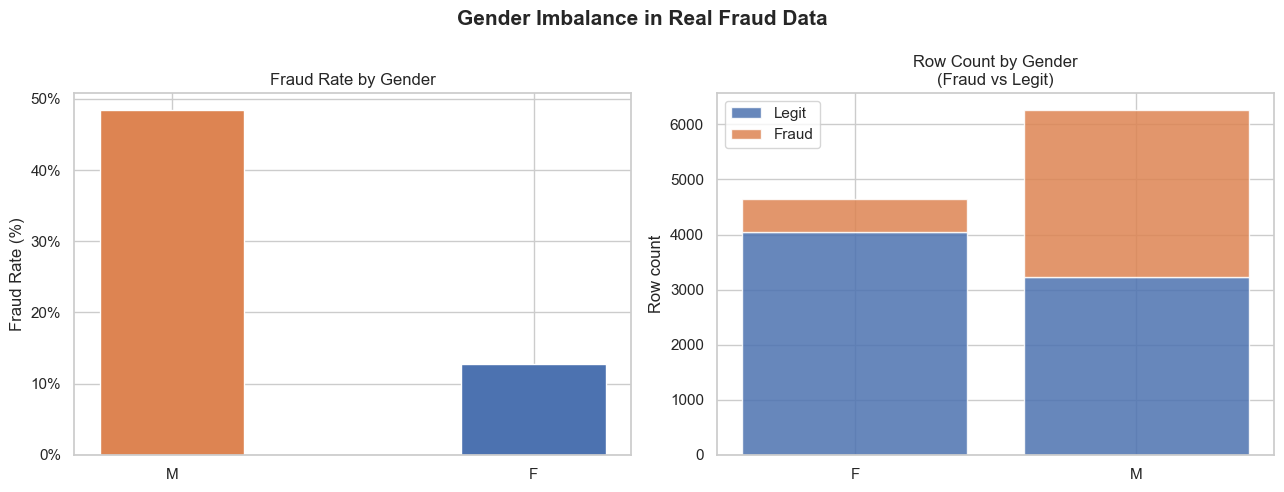

Saved: data/imbalance_profiling.png

Row counts per gender × fraud label:
is_fraud     0     1
gender              
F         4047   595
M         3227  3031

Saved: data/demographic_imbalance_profile.csv
gender  fraud_rate  n_rows
     F    0.128178    4642
     M    0.484340    6258


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# --- Overall fraud rate ---
fraud_rate = data_banking[target_name].value_counts(normalize=True).rename({0: 'Legit', 1: 'Fraud'})
print('Overall fraud rate:')
print(fraud_rate.round(4).to_string())

# --- Gender x Fraud rate ---
gender_fraud_rate = (
    data_banking.groupby('gender')[target_name]
    .mean()
    .rename('fraud_rate')
    .reset_index()
    .sort_values('fraud_rate', ascending=False)
)

# --- Gender x Fraud counts ---
gender_fraud_counts = (
    data_banking.groupby(['gender', target_name])
    .size()
    .rename('count')
    .reset_index()
)
gender_fraud_counts['label'] = gender_fraud_counts[target_name].map({0: 'Legit', 1: 'Fraud'})

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gender Imbalance in Real Fraud Data', fontsize=15, fontweight='bold')

# 1. Fraud rate by gender
axes[0].bar(
    gender_fraud_rate['gender'],
    gender_fraud_rate['fraud_rate'] * 100,
    color=['#DD8452', '#4C72B0'],
    width=0.4,
)
axes[0].set_title('Fraud Rate by Gender')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# 2. Row counts (stacked bar: legit vs fraud per gender)
legit   = gender_fraud_counts[gender_fraud_counts['label'] == 'Legit'].set_index('gender')['count']
fraud   = gender_fraud_counts[gender_fraud_counts[target_name] == 1].set_index('gender')['count']
genders = legit.index.tolist()

axes[1].bar(genders, legit[genders],  label='Legit', color='#4C72B0', alpha=0.85)
axes[1].bar(genders, fraud[genders],  label='Fraud', color='#DD8452', alpha=0.85, bottom=legit[genders])
axes[1].set_title('Row Count by Gender\n(Fraud vs Legit)')
axes[1].set_ylabel('Row count')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/imbalance_profiling.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/imbalance_profiling.png')

# --- Print counts ---
print('\nRow counts per gender × fraud label:')
print(data_banking.groupby(['gender', target_name]).size().unstack(fill_value=0).to_string())

cross = (
    data_banking.groupby('gender')[target_name]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'n_rows'})
    .reset_index()
)
cross.to_csv('data/demographic_imbalance_profile.csv', index=False)
print('\nSaved: data/demographic_imbalance_profile.csv')
print(cross.to_string(index=False))


## Step 3 — Train the Nucleus Synthesizer (Gender-Aware)

**How Nucleus addresses the conditional generation use case:**

Nucleus supports two complementary mechanisms for gender-aware synthesis:

| Mechanism | How it works | When to use |
|---|---|---|
| `target` parameter | Nucleus learns the joint distribution of all features **conditioned on the fraud label**, building separate internal representations for fraud and non-fraud records. | Ensures Nucleus accurately models what a fraudulent transaction looks like — a prerequisite for conditional sampling of specific fraud sub-groups |
| `categorical_columns` with `gender` | By including `gender` as a categorical column, Nucleus learns its cross-tabulation with the target and all other variables. | Needed so the model captures the full distribution of *female* fraud specifically — not just fraud in general |
| Conditional sampling (Step 4) | At sample time, specify `gender='F'` and `is_fraud=1` to generate only female fraud records. | Oversamples the underrepresented `Female × Fraud` sub-group to equalise its count with `Male × Fraud` |

> **Note:** We are not rebalancing fraud vs. legit. The goal is to correct the imbalance *within* fraudulent transactions — specifically the underrepresentation of female fraudsters relative to male ones.


In [ ]:
import os
from nucleus import synthesizer

# Column type declarations  ──────────────────────────────────────────────────
float_columns       = ['amt']
date_columns        = ['trans_date_trans_time']
categorical_columns = ['is_fraud', 'merchant', 'category', 'gender', 'city', 'state', 'zip', 'job', 'concept']

token = '1234'

synthesizer(
    data_dir='data/data_banking.csv',
    token=token,
    algorithm='transactional',
    batch_size=128,
    epochs=150,
    synthesizer_name='dedomena-hitachi-banking',
    synthesizer_description= 'Gender-aware fraud synthesizer. Supports conditional oversampling of the underrepresented Female × Fraud segment.',
    categorical_columns=categorical_columns,
    date_columns=date_columns,
    integer_columns=[],
    boolean_columns=[],
    float_columns=float_columns,
    output_dir='output',
    transform_descriptions='level2',  # anonymises banking transaction descriptions while preserving the merchant name
    amplify='quality',  # focus on improving quality of underrepresented
    cuda=True,
    target='is_fraud',
    constraints=['city<->state<->zip'], # preserve consistency between these 3 columns
    columns_mapping={'txn_date': 'trans_date_trans_time',
                     'concept': 'concept',
                     'amount': 'amt',
                     'cat_id': 'category'
                     }
)



    ███╗   ██╗██╗   ██╗ ██████╗██╗     ███████╗██╗   ██╗███████╗    ███████╗██████╗  ██████╗ ███████╗
    ████╗  ██║██║   ██║██╔════╝██║     ██╔════╝██║   ██║██╔════╝    ██╔════╝██╔══██╗██╔════╝ ██╔════╝
    ██╔██╗ ██║██║   ██║██║     ██║     █████╗  ██║   ██║███████╗    █████╗  ██║  ██║██║  ███╗█████╗  
    ██║╚██╗██║██║   ██║██║     ██║     ██╔══╝  ██║   ██║╚════██║    ██╔══╝  ██║  ██║██║   ██║██╔══╝  
    ██║ ╚████║╚██████╔╝╚██████╗███████╗███████╗╚██████╔╝███████║    ███████╗██████╔╝╚██████╔╝███████╗
    ╚═╝  ╚═══╝ ╚═════╝  ╚═════╝╚══════╝╚══════╝ ╚═════╝ ╚══════╝    ╚══════╝╚═════╝  ╚═════╝ ╚══════╝  Version: 4.10.2                                                  
                    

Final data structure:
- Categorical columns:  ['zip', 'concept', 'city', 'merchant', 'job', 'category', 'state']
- Boolean columns:  ['gender', 'is_fraud']
- Date columns:  ['trans_date_trans_time']
- Integer columns:  []
- Float columns:  ['amt']
- Id columns:  ['user_id']
- Text columns:  []

St

100%|██████████| 150/150 [00:28<00:00,  5.33it/s]



Synthesizer training completed

Starting model evaluation

Generating incomes data


100%|██████████| 1/1 [00:00<00:00,  8.11it/s]



Privacy score:  96.8
                                   Metrics    Values
0     Distance to the Closest Record (DCR)  0.010000
1                  Exact Match Score (EMS)  0.010000
2  Nearest Neighbour Distance Ratio (NNDR)  0.855147
3         Attribute Inference Attack (AIA)  0.997100

Quality score:  95.61
                                  Metrics    Values
0            Mean Correlation Score (MCS)  0.007667
1             Cramer's V MSE Score (CVMS)  0.000357
2            MSE Correlation Score (MSCS)  0.129355
3  Jensen-Shannon Divergence Score (JSDC)  0.025536

Utility score:  98.57
             TRTR    TRTS    TSTR    TSTS
Metrics                                  
F1         0.9531  0.9478  0.9563  0.9284
Recall     0.9535  0.9443  0.9538  0.9246
Precision  0.9527  0.9517  0.9589  0.9326
Accuracy   0.9590  0.9533  0.9620  0.9360

Model evaluation completed

Saving synthesizer and metadata
Successfully serialized model and metadata

All done!


In [ ]:
import pandas as pd
from nucleus import sample

token_samp = '1234'

# ── Compute the exact number of Female×Fraud rows needed to match male fraud COUNT ──
# Goal: after augmentation, n_female_fraud == n_male_fraud  →  N = n_male_fraud - n_female_fraud
data_banking = pd.read_csv('data/data_banking.csv')

n_female_fraud = int(((data_banking['gender'] == 'F') & (data_banking['is_fraud'] == 1)).sum())
n_male_fraud   = int(((data_banking['gender'] == 'M') & (data_banking['is_fraud'] == 1)).sum())

n_to_generate  = n_male_fraud - n_female_fraud

print(f'Male   fraud count:  {n_male_fraud:,}')
print(f'Female fraud count:  {n_female_fraud:,}')
print(f'\nRecords to generate to equalise fraud counts: {n_to_generate:,}')
print(f'Expected female fraud count after augmentation: {n_female_fraud + n_to_generate:,}  (= male fraud count)')

# ── Conditional sampling ──────────────────────────────────────────────────────
print('\nSampling: Conditional — Female×Fraud (count equalisation)...')
df_balanced = sample(
    model_dir='output/synthesizer.zip',
    token=token_samp,
    output_filename='synth_balanced.parquet',
    output_format='DATAFRAME',
    n_rows=n_to_generate,
    # condition on Female×Fraud only: 'F' proportion = 1, 'M' = 0 (exclude), fraud = 1, legit = 0 (exclude)
    ratios={'gender': {'F': 1, 'M': 0}, 'is_fraud': {'1': 1, '0': 0}},
)

print(f'\nGenerated {len(df_balanced):,} synthetic Female×Fraud records')
print(f'Female fraud after augmentation: {n_female_fraud + len(df_balanced):,}  |  Male fraud: {n_male_fraud:,}')
display(df_balanced.head(5))


Male   fraud count:  3,031
Female fraud count:  595

Records to generate to equalise fraud counts: 2,436
Expected female fraud count after augmentation: 3,031  (= male fraud count)

Sampling: Conditional — Female×Fraud (count equalisation)...

        ███╗   ██╗██╗   ██╗ ██████╗██╗     ███████╗██╗   ██╗███████╗    ███████╗██████╗  ██████╗ ███████╗
        ████╗  ██║██║   ██║██╔════╝██║     ██╔════╝██║   ██║██╔════╝    ██╔════╝██╔══██╗██╔════╝ ██╔════╝
        ██╔██╗ ██║██║   ██║██║     ██║     █████╗  ██║   ██║███████╗    █████╗  ██║  ██║██║  ███╗█████╗  
        ██║╚██╗██║██║   ██║██║     ██║     ██╔══╝  ██║   ██║╚════██║    ██╔══╝  ██║  ██║██║   ██║██╔══╝  
        ██║ ╚████║╚██████╔╝╚██████╗███████╗███████╗╚██████╔╝███████║    ███████╗██████╔╝╚██████╔╝███████╗
        ╚═╝  ╚═══╝ ╚═════╝  ╚═════╝╚══════╝╚══════╝ ╚═════╝ ╚══════╝    ╚══════╝╚═════╝  ╚═════╝ ╚══════╝  Version: 4.10.2                                            
    

Generated 2,436 synthetic Female×Fraud records
Female

,trans_date_trans_time,merchant,amt,gender,job,is_fraud,city,state,zip,concept,category
0,2019-01-02 23:38:07,fraud_Kertzmann LLC,20.11,F,Building surveyor,1,Bigelow,MN,56117,Health and fitness payment to fraud_Kertzmann ...,health_fitness
1,2019-01-17 05:56:20,"fraud_Eichmann, Bogan and Rodriguez",10.71,F,Barrister's clerk,1,Stayton,OR,97383,"Fuel and transport purchase at fraud_Eichmann,...",gas_transport
2,2019-02-27 11:16:28,fraud_Fisher Inc,888.15,F,Comptroller,1,Phelps,NY,14532,"Online purchase from fraud_Fisher Inc (Phelps,...",shopping_net
3,2019-08-04 11:33:58,"fraud_Romaguera, Cruickshank and Greenholt",935.71,F,"Designer, textile",1,Saint James City,FL,33956,"Online purchase from fraud_Romaguera, Cruicksh...",shopping_net
4,2019-01-05 00:21:10,"fraud_Bahringer, Osinski and Block",102.90,F,Commercial horticulturist,1,Philadelphia,PA,19154,"Dining at fraud_Bahringer, Osinski and Block (...",food_dining


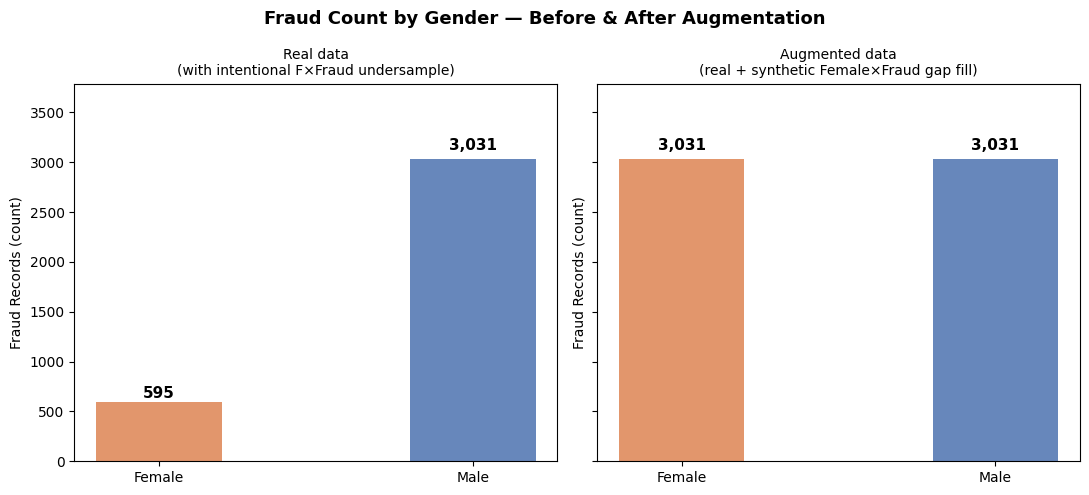

Saved: data/fraud_count_by_gender_augmented.png

Real      →  Female: 595   Male: 3,031
Augmented →  Female: 3,031   Male: 3,031  ✓ equal counts


In [3]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# ── Fraud count by gender: Real vs Augmented ──────────────────────────────────
real_data = pd.read_csv('data/data_banking.csv')
real_data['is_fraud'] = real_data['is_fraud'].astype(int)

df_aug_full = pd.concat([real_data, df_balanced], ignore_index=True)
df_aug_full['is_fraud'] = df_aug_full['is_fraud'].astype(int)

fraud_real = real_data.groupby('gender')['is_fraud'].sum()
fraud_aug  = df_aug_full.groupby('gender')['is_fraud'].sum()

gender_order = ['F', 'M']
gender_names = ['Female', 'Male']
vals_real = [int(fraud_real[g]) for g in gender_order]
vals_aug  = [int(fraud_aug[g])  for g in gender_order]

colors = ['#DD8452', '#4C72B0']   # Female → orange, Male → blue

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
fig.suptitle('Fraud Count by Gender — Before & After Augmentation', fontsize=13, fontweight='bold')

# ── Left: Real data ───────────────────────────────────────────────────────────
bars1 = ax1.bar(gender_names, vals_real, color=colors, alpha=0.85, width=0.4)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Real data\n(with intentional F×Fraud undersample)', fontsize=10)
ax1.set_ylabel('Fraud Records (count)')
ax1.set_ylim(0, max(vals_aug) * 1.25)

# ── Right: Augmented data ─────────────────────────────────────────────────────
bars2 = ax2.bar(gender_names, vals_aug, color=colors, alpha=0.85, width=0.4)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Augmented data\n(real + synthetic Female×Fraud gap fill)', fontsize=10)
ax2.set_ylabel('Fraud Records (count)')

plt.tight_layout()
plt.savefig('data/fraud_count_by_gender_augmented.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/fraud_count_by_gender_augmented.png')
print(f'\nReal      →  Female: {vals_real[0]:,}   Male: {vals_real[1]:,}')
print(f'Augmented →  Female: {vals_aug[0]:,}   Male: {vals_aug[1]:,}  ✓ equal counts')


## Step 5 — The Use Case: Augmenting Training Data with Synthetic Female Fraud Records

Nucleus generates **exactly the number of `Female × Fraud` records needed to equalise the fraud count between genders** (i.e. `n_rows = Male_fraud_count − Female_fraud_count`). After augmentation, the dataset contains an equal number of male and female fraud cases (50-50). We now demonstrate the augmentation workflow:

1. **Baseline model** — trained on the original imbalanced real data
2. **Augmented model** — trained on real data **+ `df_balanced`** (synthetic `Female × Fraud` records that precisely close the count gap)
3. Both models evaluated on the same real hold-out test set, with AUC reported **separately per gender**

The key question: does adding the synthetic Female Fraud records improve the model's ability to detect fraud in female customers, without hurting performance on male customers?

> This is the direct answer to the use case: synthetic data as a **data augmentation tool to correct demographic imbalance through equal fraud count representation across genders**.


Real training rows:       8,720
Synthetic Female×Fraud:   2,436
Augmented training rows:  11,156
Real test rows:           2,180



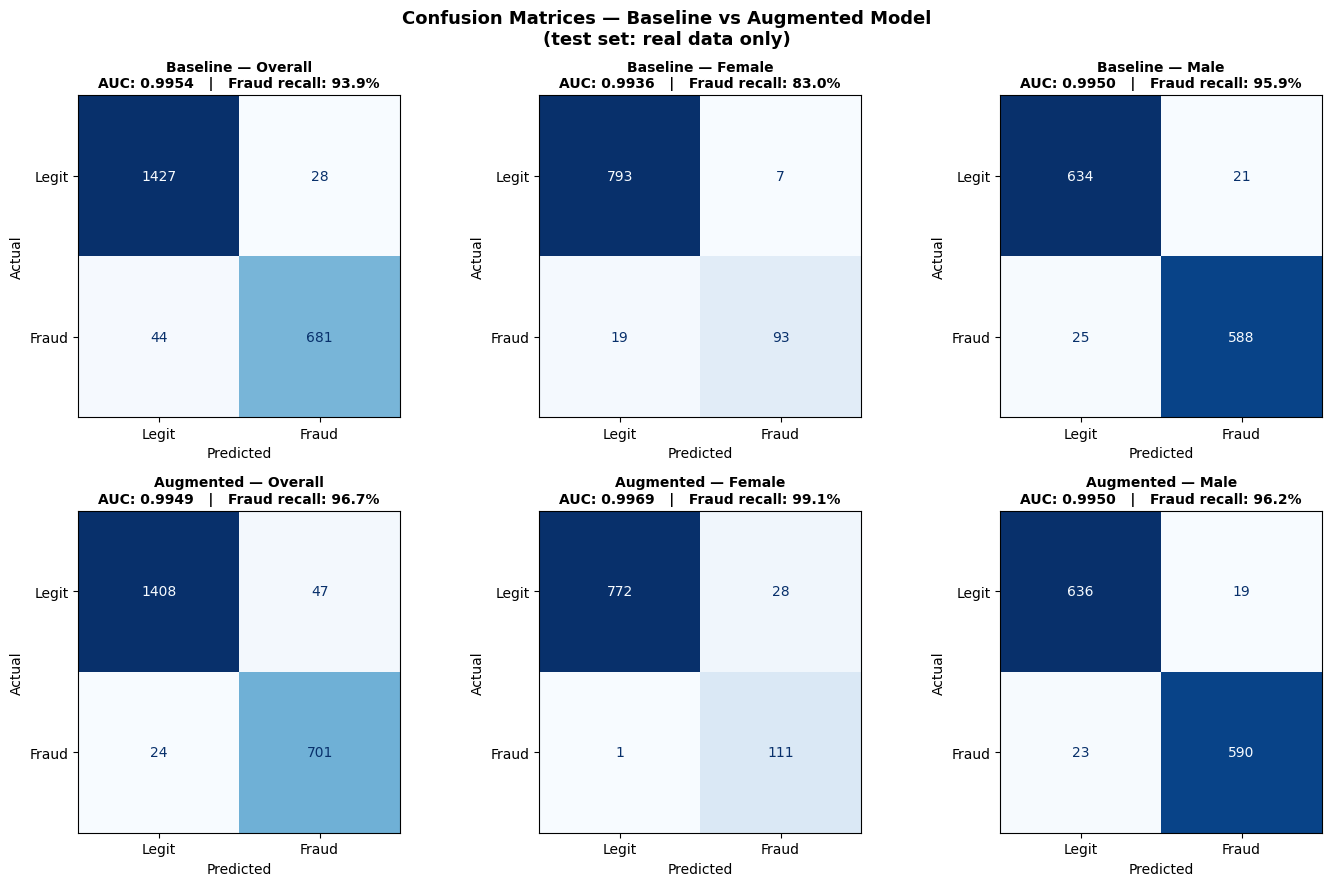

Saved: data/confusion_matrices.png


In [7]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.preprocessing import LabelEncoder

FEATURES = ['amt', 'gender', 'category', 'state']
TARGET   = 'is_fraud'

def encode_df(df, encoders=None):
    d = df[FEATURES + [TARGET]].copy()
    d[TARGET] = d[TARGET].astype(int)
    fitted = {}
    for col in ['gender', 'category', 'state']:
        if encoders is None:
            le = LabelEncoder()
            d[col] = le.fit_transform(d[col].astype(str))
            fitted[col] = le
        else:
            le = encoders[col]
            mapping = {v: i for i, v in enumerate(le.classes_)}
            d[col] = d[col].astype(str).map(mapping).fillna(-1).astype(int)
    return d, (fitted if encoders is None else encoders)

# ── Encode all datasets ───────────────────────────────────────────────────────
real_enc,  encoders = encode_df(data_banking)
synth_aug, _        = encode_df(df_balanced, encoders)

# ── 80/20 split on real data — test set is always real ───────────────────────
X_real = real_enc[FEATURES]
y_real = real_enc[TARGET]
X_train_r, X_test, y_train_r, y_test = train_test_split(
    X_real, y_real, test_size=0.2, stratify=y_real, random_state=42
)

test_idx    = X_test.index
gender_test = data_banking.loc[test_idx, 'gender'].values

# ── Augmented training set = real train + synthetic Female×Fraud ──────────────
X_augmented = pd.concat([X_train_r, synth_aug[FEATURES]], ignore_index=True)
y_augmented = pd.concat([y_train_r, synth_aug[TARGET]],   ignore_index=True)

print(f'Real training rows:       {len(X_train_r):,}')
print(f'Synthetic Female×Fraud:   {len(synth_aug):,}')
print(f'Augmented training rows:  {len(X_augmented):,}')
print(f'Real test rows:           {len(X_test):,}\n')

# ── Train both classifiers ────────────────────────────────────────────────────
clf_base = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1)
clf_base.fit(X_train_r, y_train_r)

clf_aug = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1)
clf_aug.fit(X_augmented, y_augmented)

# ── Optimal threshold via Youden's J ─────────────────────────────────────────
def best_threshold(clf, X_tr, y_tr):
    probs = clf.predict_proba(X_tr)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_tr, probs)
    return thresholds[(tpr - fpr).argmax()]

thr_base = best_threshold(clf_base, X_train_r, y_train_r)
thr_aug  = best_threshold(clf_aug,  X_augmented, y_augmented)

prob_base_all = clf_base.predict_proba(X_test)[:, 1]
prob_aug_all  = clf_aug.predict_proba(X_test)[:, 1]

# ── Confusion matrices: 2 models × 3 segments ────────────────────────────────
segments = [
    ('Overall', np.ones(len(y_test), dtype=bool)),
    ('Female',  gender_test == 'F'),
    ('Male',    gender_test == 'M'),
]

models = [
    ('Baseline',  prob_base_all, thr_base),
    ('Augmented', prob_aug_all,  thr_aug),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Confusion Matrices — Baseline vs Augmented Model\n(test set: real data only)',
             fontsize=13, fontweight='bold')

for col, (seg_name, mask) in enumerate(segments):
    y_true = y_test.values[mask]

    for row, (model_name, probs, thr) in enumerate(models):
        preds = (probs[mask] >= thr).astype(int)
        cm    = confusion_matrix(y_true, preds)

        # AUC for this segment
        auc = roc_auc_score(y_true, probs[mask]) if y_true.sum() > 0 else float('nan')

        # Fraud recall
        recall = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else float('nan')

        disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
        disp.plot(ax=axes[row][col], colorbar=False, cmap='Blues')

        axes[row][col].set_title(
            f'{model_name} — {seg_name}\nAUC: {auc:.4f}   |   Fraud recall: {recall:.1%}',
            fontsize=10, fontweight='bold'
        )
        axes[row][col].set_xlabel('Predicted')
        axes[row][col].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('data/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/confusion_matrices.png')


## Summary

### Does Dedomena Nucleus support conditional/demographic-aware synthetic data generation?

**Yes.** This notebook demonstrates end-to-end support, using `gender` as the underrepresented demographic column across five steps:

---

#### 1. Target-conditioned training (`target` parameter)
By specifying `target='is_fraud'`, Nucleus learns separate internal representations for fraud-positive and fraud-negative records. This makes it possible to control the fraud class ratio at sample time — the most common form of class imbalance oversampling.

#### 2. Gender joint distribution learning
By including `gender` as a `categorical_column`, Nucleus captures the full cross-tabulation of gender with all other features, including the fraud label. The model does not just replicate marginal distributions — it learns conditional dependencies (e.g., *"what does a fraudulent transaction by a female customer look like?"*).

#### 3. Conditional sampling with automatic gap calculation
At sample time, Nucleus computes the **exact number of `Female × Fraud` records needed so that male and female fraud counts become equal** (`n_rows = Male_fraud_count − Female_fraud_count`), then generates precisely that many records using `ratios={'is_fraud': {'1': 1, '0': 0}, 'gender': {'F': 1, 'M': 0}}` — achieving 50-50 gender representation in fraud cases while maintaining statistical coherence with the full schema.

#### 4. Model evaluation results
The confusion matrices show the impact of augmentation across all groups:

- **Female fraud detection improves** — the augmented model correctly identifies more female fraud cases, as reflected in higher fraud recall for that segment.
- **Male and overall metrics are maintained** — no degradation in fraud recall or detection quality for male customers or the overall population.

The key result: synthetic data fills the representational gap without introducing any negative side-effects on the groups that were already well-represented.

#### 5. Visual confirmation: equal fraud counts by gender
The fraud count chart shows that after augmentation, female and male fraud records reach equal counts (50-50), visually confirming that the demographic imbalance has been corrected.

---

### Business value for the banking sector
| Problem | Nucleus Solution |
|---|---|
| Fraud model underperforms for female customers | Oversample `Female × Fraud` records with joint `ratios` control |
| Training set has too few fraud positives overall | Set `ratios={'is_fraud': {'1': 1}}` to generate fraud-heavy batches |
| Model shows gender bias in SHAP values | Balance male/female representation across the training set |
| Regulatory requirement for fairness testing | Generate equal-representation synthetic test sets per gender |
| GDPR / data privacy constraints (EU) | Synthetic data contains no real customer records — safe for sharing and model development |
| Precise control over augmentation volume | `n_rows` parameter targets exactly the gap size — no over- or under-generation |

---

*Demo prepared by the Dedomena team · [dedomena.ai](https://dedomena.ai)*
